# Dual-Parameter CMB Predictor

This notebook implements a dual-parameter predictor for CMB analysis that simultaneously predicts both fnl and phi_scales parameters from lensed CMB maps.

## Setup and Imports

In [18]:
import os
import sys
import json
import math
import copy
import logging
import h5py
import numpy as np
import healpy as hp
import lenspyx
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed

# Suppress TensorFlow warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Flatten, Add, Input, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# Add deepsphere path if needed
sys.path.append("/users/stevensonb/Research/tools/deepsphere-cosmo-tf2")

from deepsphere import HealpyGCNN
from deepsphere.healpy_layers import (
    HealpyChebyshev,
    HealpyPool,
)

from mlpng import Core
from mlpng.utils import get_data, setup_logging
from mlpng.utils.dataloaders import MapDataset

# Setup logging
logger = setup_logging("mlpng.double_model", level=logging.DEBUG)

# Set plot style
plt.style.use("seaborn-v0_8-paper")
plt.rc("font", family="serif")
plt.rc("figure", figsize=(12, 8))

print("TensorFlow version:", tf.__version__)
print("GPUs available:", len(tf.config.list_physical_devices("GPU")))

TensorFlow version: 2.15.1
GPUs available: 1


## Load Settings and Configuration

In [19]:
# Initialize Core object with settings
core = Core(
    [
        "settings/n64.json",
        "--nsims",
        "10000",
        "--shapes",
        "local",
        "--fnl_range",
        "-1000",
        "1000",
    ]
)

# Extract parameters from core
nside = core.nside
nsims = core.nsims
npix = hp.nside2npix(nside)
npols = core.npols if hasattr(core, "npols") else 1
shapes = core.shapes
nshapes = len(shapes)

18-Nov-25 21:34:25 - mlpng.core - DEBUG - Parsing CLI args: ['settings/n64.json', '--nsims', '10000', '--shapes', 'local', '--fnl_range', '-1000', '1000']
18-Nov-25 21:34:25 - mlpng.core - INFO - Loading settings from file 'settings/n64.json'
18-Nov-25 21:34:25 - mlpng.core - DEBUG - Forcing setting 'nsims' to 10000 due to CLI
18-Nov-25 21:34:25 - mlpng.core - DEBUG - Forcing setting 'fnl_range' to [-1000, 1000] due to CLI
18-Nov-25 21:34:25 - mlpng.core - DEBUG - Forcing setting 'shapes' to ['local'] due to CLI
18-Nov-25 21:34:25 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.105e-09
18-Nov-25 21:34:25 - mlpng.core - DEBUG - Overriding cosmo param 'ns' from 0.9624 to 0.965
18-Nov-25 21:34:25 - mlpng.core - DEBUG - Running with settings: 
{
  "cosmo_params": {
    "As": 2.105e-09,
    "ns": 0.965,
    "pivot_scalar": 0.05,
    "H0": 67.4,
    "ombh2": 0.0224,
    "omch2": 0.12,
    "tau": 0.054
  },
  "nsims": 10000,
  "nside": 64,
  "fnl_range": [
    -1000,
   

## Custom DualParameterDataset Class

This dataset generates lensed CMB maps with random pairs of (fnl, phi_scales) parameters.

In [20]:
class DualParameterDataset(MapDataset):
    """
    Dataset for dual-parameter prediction of fnl and phi_scales.

    Generates lensed CMB maps with random pairs of (fnl, phi_scales) parameters
    by directly loading unlensed ALMs, applying lensing with phi_scale-dependent
    lensing potential, and converting to maps. All lensing is done during data
    generation so it gets cached.
    """

    @classmethod
    def fromCore(
        cls, core, lensed=True, phi_scale_min=0.0, phi_scale_max=100.0, **kwargs
    ):
        """
        Create dataset from Core object, defaulting to local shape only.

        Args:
            core: Core configuration object
            lensed: Whether to use lensed maps (default: True)
            phi_scale_min: Minimum phi_scale value (default: 0.0)
            phi_scale_max: Maximum phi_scale value (default: 100.0)
        """
        shapes = kwargs.pop("shapes", core.shapes)
        x_shape = kwargs.pop("x_shape", (None, core.npix, core.npols))
        x_dtype = kwargs.pop("x_dtype", tf.float32)
        nside = kwargs.pop("nside", core.nside)
        y_shape = kwargs.pop("y_shape", (None, len(shapes) + 1))

        return cls(
            file_path=kwargs.pop("file_path", core.file),
            nside=nside,
            shapes=shapes,
            fnl_min=kwargs.pop("fnl_min", core.fnl_min),
            fnl_max=kwargs.pop("fnl_max", core.fnl_max),
            phi_scale_min=phi_scale_min,
            phi_scale_max=phi_scale_max,
            lensed=lensed,
            fnl_seed=kwargs.pop("fnl_seed", 42),
            x_shape=x_shape,
            x_dtype=x_dtype,
            y_shape=y_shape,
            y_dtype=kwargs.pop("y_dtype", tf.float32),
            core=core,
            **kwargs,
        )

    def __init__(
        self,
        file_path,
        nside,
        shapes=None,
        fnl_min=-1000.0,
        fnl_max=1000.0,
        phi_scale_min=0.0,
        phi_scale_max=100.0,
        lensed=True,
        fnl_seed=42,
        x_shape=None,
        x_dtype=tf.float32,
        y_shape=None,
        y_dtype=tf.float32,
        core=None,
        **kwargs
    ):
        self.phi_scale_min = phi_scale_min
        self.phi_scale_max = phi_scale_max
        self.lensed = lensed
        self.core = core
        self.gaussian_mask = False

        if shapes is None:
            shapes = ["local"]
        elif isinstance(shapes, str):
            shapes = [shapes]

        if y_shape is None:
            y_shape = (None, len(shapes) + 1)

        super().__init__(
            file_path=file_path,
            nside=nside,
            shapes=shapes,
            fnl_min=fnl_min,
            fnl_max=fnl_max,
            fnl_seed=fnl_seed,
            x_shape=x_shape,
            x_dtype=x_dtype,
            y_shape=y_shape,
            y_dtype=y_dtype,
            **kwargs,
        )

        self._setup_lensing_geometry()

    def _setup_lensing_geometry(self):
        """Pre-compute lenspyx geometry for lensing operations."""
        self.geom_info = ("healpix", {"nside": self.nside})
        self.geom = lenspyx.get_geom(self.geom_info)
        self.lmax = 3 * self.nside - 1
        self.lmax_len = self.lmax + 100
        fl = np.sqrt(np.arange(self.lmax_len + 1) * np.arange(1, self.lmax_len + 2))
        self.fl = fl

    def _generate_parameters(self, indices, duplicates):
        """Generate random fnl and phi_scale parameters with independent seeding."""
        batch_size = len(indices)
        nshapes = len(self.shapes)

        np.random.seed(self.fnl_seed + indices[0])
        fnls = np.random.uniform(
            low=self.fnl_min,
            high=self.fnl_max,
            size=(duplicates, batch_size, nshapes),
        )

        np.random.seed(self.fnl_seed + indices[0] + 1)
        phi_scales = np.random.uniform(
            low=self.phi_scale_min,
            high=self.phi_scale_max,
            size=(duplicates, batch_size, 1),
        )

        fnls = fnls.transpose(1, 0, 2).reshape(batch_size * duplicates, nshapes)
        phi_scales = phi_scales.transpose(1, 0, 2).reshape(batch_size * duplicates, 1)

        if self.gaussian_mask:
            zero_prob = 0.1
            for i in range(batch_size * duplicates):
                if np.random.rand() < zero_prob:
                    fnls[i, :] = 0
                if np.random.rand() < zero_prob:
                    phi_scales[i, 0] = 0

        return fnls, phi_scales

    def _lens_alms(self, indices, duplicates, fnls, phi_scales):
        """
        Load unlensed ALMs and apply lensing with phi_scale-dependent potential.
        """
        batch_size = len(indices)
        nshapes = len(self.shapes)

        alm_l = get_data(self.file_path, f"alm_l/{self.l_str}", indices)
        alm_nl = np.array(
            [
                get_data(self.file_path, f"alm_nl/{self.l_str}/{s}", indices)
                for s in self.shapes
            ]
        )

        # Load alm_phi from data file
        alm_phi_all = get_data(self.file_path, "alm_phi", indices)

        alms_lensed = np.zeros(
            (batch_size * duplicates, alm_l.shape[1], alm_l.shape[2]),
            dtype=np.complex128,
        )

        for sim_idx in range(batch_size):
            for dup_idx in range(duplicates):
                output_idx = sim_idx * duplicates + dup_idx

                fnl_vals = fnls[output_idx, :]

                alm = np.asarray(alm_l[sim_idx], dtype=np.complex128) + np.einsum(
                    "i,i...->...", fnl_vals, alm_nl[:, sim_idx]
                )
                alm = np.asarray(alm, dtype=np.complex128)

                phi_scale = phi_scales[output_idx, 0]
                # Load alm_phi and multiply by phi_scale
                alm_phi = alm_phi_all[sim_idx] * phi_scale

                dlm = hp.almxfl(alm_phi, self.fl)

                alm_t = np.asarray(alm[0], dtype=np.complex128)
                lenmap = lenspyx.alm2lenmap(
                    alm_t,
                    dlm,
                    geometry=self.geom_info,
                    nthreads=1,
                )
                lenmap = np.ascontiguousarray(lenmap)

                alm_lensed_t = self.geom.map2alm(
                    lenmap,
                    self.lmax,
                    self.lmax,
                    nthreads=1,
                )

                alm_lensed_t = np.asarray(alm_lensed_t, dtype=np.complex128)

                if alm.shape[0] == 1:
                    alms_lensed[output_idx, 0, : len(alm_lensed_t)] = alm_lensed_t
                else:
                    alms_lensed[output_idx, 0, : len(alm_lensed_t)] = alm_lensed_t
                    alms_lensed[output_idx, 1:, :] = alm[1:, :]

        return alms_lensed

    def _generate(self, indices, duplicates):
        """
        Generate a batch of CMB maps with dual parameters (fnl and phi_scales).
        """
        batch_size = len(indices)
        nshapes = len(self.shapes)

        fnls, phi_scales = self._generate_parameters(indices, duplicates)
        alms_lensed = self._lens_alms(indices, duplicates, fnls, phi_scales)

        n_cpus = len(os.sched_getaffinity(0))
        n_jobs = min(n_cpus, batch_size * duplicates)
        with Parallel(n_jobs, pre_dispatch="n_jobs", prefer="threads") as p:
            maps = p(
                delayed(self._alm_to_map)(alm, self.rotate, self.nside)
                for alm in alms_lensed
            )

        # maps is a list of (npix,) arrays, stack to (batch*duplicates, npix, 1)
        maps = np.array(maps)  # Shape: (batch*duplicates, npix)
        # maps = maps[:, np.newaxis, :]
        maps = np.transpose(maps, (0, 2, 1))
        print(maps.shape)

        params = np.hstack([fnls, phi_scales])

        return maps, params

## Model Architecture - DualParameterModel

This model uses a ResidualHealpyUNet encoder (without decoder) followed by separate dense networks for fnl and phi_scales prediction.

In [21]:
@tf.keras.saving.register_keras_serializable()
class EncoderBlock(tf.keras.layers.Layer):
    """Encoder block using HEALPix convolutions."""

    def __init__(
        self,
        nside,
        npix,
        fin,
        fout,
        activation,
        max_batch_size,
        K,
        use_bn=True,
        use_bias=False,
        pool=True,
        dropout_rate=0.1,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.nside = nside
        self.npix = npix
        self.fin = fin
        self.fout = fout
        self.activation_fn = activation
        self.max_batch_size = max_batch_size
        self.K = K
        self.use_bn = use_bn
        self.use_bias = use_bias
        self.dropout_rate = dropout_rate
        self.pool = pool
        indices = np.arange(npix)

        enc_layers = [
            HealpyChebyshev(
                K=K,
                Fout=fout,
                activation=activation,
                use_bn=use_bn,
                use_bias=use_bias,
            ),
            HealpyChebyshev(
                K=K,
                Fout=fout,
                activation=activation,
                use_bn=use_bn,
                use_bias=use_bias,
            ),
        ]
        if dropout_rate > 0.0:
            enc_layers.append(Dropout(dropout_rate))

        self.body = HealpyGCNN(
            nside=nside,
            indices=indices,
            layers=enc_layers,
            n_neighbors=8,
            max_batch_size=max_batch_size,
            initial_Fin=fin,
        )

        self.pooler = None
        if pool:
            self.pooler = HealpyGCNN(
                nside=nside,
                indices=indices,
                layers=[HealpyPool(1, "AVG")],
                n_neighbors=8,
                max_batch_size=max_batch_size,
                initial_Fin=fout,
            )

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "nside": self.nside,
                "npix": self.npix,
                "fin": self.fin,
                "fout": self.fout,
                "activation": self.activation_fn,
                "max_batch_size": self.max_batch_size,
                "K": self.K,
                "use_bn": self.use_bn,
                "use_bias": self.use_bias,
                "pool": self.pool,
                "dropout_rate": self.dropout_rate,
            }
        )
        return config

    def call(self, inputs, training=False):
        x = skip = self.body(inputs, training=training)
        if self.pool:
            x = self.pooler(x, training=training)
        return x, skip


def create_dual_parameter_model(input_shape, nshapes=3, max_batch_size=32):
    """
    Create a dual-parameter prediction model with separate outputs for fnl and phi_scale.

    Args:
        input_shape: Tuple (batch, npix, npols)
        nshapes: Number of fnl shape parameters (default: 3 for local, equilateral, orthogonal)
        max_batch_size: Maximum batch size for HEALPix operations

    Returns:
        Compiled Keras model with separate loss tracking for each output
    """
    npix = input_shape[1]
    npol = input_shape[2]
    nside = hp.npix2nside(npix)

    # Calculate encoder depth based on nside
    depth = int(math.log2(nside))

    # Channel progression: [npol, 8, 16, 32, 64, 128, ...]
    base_channels = [npol] + [2 ** (i + 5) for i in range(depth)]
    level_npixels = [npix // (4**i) for i in range(depth + 1)]
    level_nsides = [hp.npix2nside(pix) for pix in level_npixels]

    # Chebyshev order progression: [1, 3, 5, 7, ...]
    Ks = [3 + (2 * (i // 2)) for i in range(depth + 1)]

    # Build model
    inputs = Input(shape=input_shape[1:])
    x = inputs

    # Encoder blocks
    skips = []
    for i in range(depth):
        block = EncoderBlock(
            level_nsides[i],
            level_npixels[i],
            fin=base_channels[i],
            fout=base_channels[i + 1],
            activation="gelu",
            max_batch_size=max_batch_size,
            K=Ks[i],
            dropout_rate=0.1,
            use_bias=True,
            use_bn=True,
        )
        x, skip = block(x)
        skips.append(skip)

    # Flatten the encoder output
    x = Flatten()(x)

    # Dense network for fnl prediction
    fnl_branch = Dense(32, activation="relu", name="fnl_dense1")(x)
    fnl_branch = Dense(32, activation="relu", name="fnl_dense2")(fnl_branch)
    # fnl_branch = Dropout(0.1)(fnl_branch)
    fnl_output = Dense(nshapes, name="fnl_output")(fnl_branch)

    # Dense network for phi_scales prediction
    phi_branch = Dense(32, activation="relu", name="phi_dense1")(x)
    phi_branch = Dense(32, activation="relu", name="phi_dense2")(phi_branch)
    # phi_branch = Dropout(0.1)(phi_branch)
    phi_output = Dense(1, name="phi_output")(phi_branch)

    # Create model with separate outputs
    model = Model(
        inputs=inputs, outputs=[fnl_output, phi_output], name="DualParameterModel"
    )

    return model

## Dataset Creation and Pipeline Setup

In [22]:
# Create dataset using Core object
dataset = DualParameterDataset.fromCore(
    core,
    lensed=True,
    phi_scale_min=0.0,
    phi_scale_max=100.0,
    rotate=False,
)

18-Nov-25 21:34:26 - mlpng.utils.dataloaders - DEBUG - Error information from 'data/data/l191_n64_T_10000_p1.0.hdf5'...
18-Nov-25 21:34:26 - mlpng.utils.dataloaders - DEBUG - Fisher Matrix: [0.00045728]
18-Nov-25 21:34:26 - mlpng.utils.dataloaders - DEBUG - Marginal Likelihoods: [46.763496]
18-Nov-25 21:34:26 - mlpng.utils.dataloaders - DEBUG - Fisher for shape local: 0.00044548727, std div: 47.378614469766276
18-Nov-25 21:34:26 - mlpng.utils.dataloaders - DEBUG - Fisher Matrix: [0.00045728]
18-Nov-25 21:34:26 - mlpng.utils.dataloaders - DEBUG - Marginal Likelihoods: [46.763496]
18-Nov-25 21:34:26 - mlpng.utils.dataloaders - DEBUG - Fisher for shape local: 0.00044548727, std div: 47.378614469766276


In [23]:
# Split dataset into train/val/test with 80/10/10 distribution and duplications
# gaussian_mask=[True, False, False] applies zero-logic only to training set
# Changed phi_scale range to [0, 100] for better learnability
train_ds, val_ds, test_ds = dataset.split(
    train_size=0.08,
    val_size=0.01,
    test_size=0.01,
    to_tf=True,
    duplicates=[25, 10, 2],
    gaussian_mask=[True, False, False],
    cache_file="double_test-0_100",
)

18-Nov-25 21:34:26 - mlpng.utils.dataloaders - DEBUG - Splitting 'data/data/l191_n64_T_10000_p1.0.hdf5' into train: 0:800 (800), val: 800:900 (100), test: 900:1000 (100)
18-Nov-25 21:34:26 - mlpng.utils.dataloaders - DEBUG - Using cache file: '/lustre/smuexa01/client/users/stevensonb/tf_cache/double_test-0_100-train.cache'
18-Nov-25 21:34:26 - mlpng.utils.dataloaders - DEBUG - Using cache file: '/lustre/smuexa01/client/users/stevensonb/tf_cache/double_test-0_100-train.cache'


18-Nov-25 21:34:26 - mlpng.utils.dataloaders - DEBUG - Using cache file: '/lustre/smuexa01/client/users/stevensonb/tf_cache/double_test-0_100-val.cache'
18-Nov-25 21:34:26 - mlpng.utils.dataloaders - DEBUG - Using cache file: '/lustre/smuexa01/client/users/stevensonb/tf_cache/double_test-0_100-test.cache'
18-Nov-25 21:34:26 - mlpng.utils.dataloaders - DEBUG - Using cache file: '/lustre/smuexa01/client/users/stevensonb/tf_cache/double_test-0_100-test.cache'


## Data Exploration and Verification

Let's verify the new direct ALM lensing implementation is working correctly with proper phi_scale integration.


In [24]:
# # Get a batch from training data
# print("Checking data from all three splits...")

# for split_name, split_ds in [("Train", train_ds), ("Val", val_ds), ("Test", test_ds)]:
#     for batch_x, batch_y in split_ds.take(1):
#         nshapes_actual = len(dataset.shapes)

#         print(f"\n{split_name} Data:")
#         print(f"  Map shape: {batch_x.shape} (batch, npix, npols)")
#         print(f"  Params shape: {batch_y.shape} (batch, nshapes+1)")

#         # Check parameter ranges
#         fnl_vals = batch_y[:, 0].numpy()
#         phi_vals = batch_y[:, 1].numpy()

#         print(
#             f"  fnl (local): min={fnl_vals.min():.1f}, max={fnl_vals.max():.1f}, mean={fnl_vals.mean():.1f}"
#         )
#         print(f"    Zero count: {(fnl_vals == 0).sum()} / {len(fnl_vals)}")
#         print(
#             f"  phi_scale: min={phi_vals.min():.3f}, max={phi_vals.max():.3f}, mean={phi_vals.mean():.3f}"
#         )
#         print(f"    Zero count: {(phi_vals == 0).sum()} / {len(phi_vals)}")

# # Visualize sample map and parameter distributions
# for batch_x, batch_y in train_ds.take(1):
#     sample_map = batch_x[0, :, 0].numpy()
#     sample_map = hp.reorder(sample_map, n2r=True)

#     hp.mollview(sample_map, title="Sample Lensed CMB Map (Direct ALM Lensing)")
#     plt.tight_layout()
#     plt.show()

#     # Plot parameter distributions
#     nshapes_actual = len(dataset.shapes)
#     fig, axes = plt.subplots(
#         1, nshapes_actual + 1, figsize=(5 * (nshapes_actual + 1), 4)
#     )

#     if nshapes_actual == 1:
#         axes = np.array([axes])

#     param_names = [f"fnl ({s})" for s in dataset.shapes] + ["phi_scale"]
#     for i, (ax, name) in enumerate(zip(axes.flat, param_names)):
#         ax.hist(
#             batch_y[:, i].numpy(),
#             bins=30,
#             edgecolor="black",
#             alpha=0.7,
#             color="skyblue",
#         )
#         ax.set_xlabel(name, fontsize=11)
#         ax.set_ylabel("Count", fontsize=11)
#         ax.set_title(f"Distribution of {name}", fontsize=12)
#         ax.grid(alpha=0.3)

#     plt.tight_layout()
#     plt.show()

## Distributed Training Setup

In [25]:
# Initialize MirroredStrategy for multi-GPU training
strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs: {strategy.num_replicas_in_sync}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
18-Nov-25 21:34:27 - tensorflow - INFO - Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
Number of GPUs: 1
18-Nov-25 21:34:27 - tensorflow - INFO - Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
Number of GPUs: 1


## Model Definition and Compilation

In [26]:
# Create and compile model within strategy scope for distributed training
with strategy.scope():
    input_shape = (None, npix, npols)
    nshapes = len(dataset.shapes)

    model = create_dual_parameter_model(
        input_shape=input_shape, nshapes=nshapes, max_batch_size=32
    )

    model.summary()

    # Compile model with separate losses for each output
    epochs = 50
    initial_learning_rate = 1e-3

    # Calculate decay steps based on training dataset size
    train_samples = int(10000 * 0.08 * 25)  # 80% of 10k with 25x duplication
    batch_size = 32  # Default batch size
    steps_per_epoch = math.ceil(train_samples / batch_size)
    decay_steps = steps_per_epoch * 3  # Decay over 3 epochs

    # Create learning rate schedule with exponential decay
    lr_schedule = ExponentialDecay(
        initial_learning_rate=initial_learning_rate,
        decay_steps=decay_steps,
        decay_rate=0.95,
        staircase=True,
    )

    # Compile with separate losses for fnl and phi_scale outputs
    # This allows TensorFlow to track loss for each output separately
    model.compile(
        optimizer=AdamW(learning_rate=lr_schedule),
        loss={
            "fnl_output": "mse",
            "phi_output": "mse",
        },
        loss_weights={
            "fnl_output": 1.0,
            "phi_output": 1.0,
        },
        # metrics={
        #     "fnl_output": [
        #         "mean_absolute_error",
        #         tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        #     ],
        #     "phi_output": [
        #         "mean_absolute_error",
        #         tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        #     ],
        # },
    )

print("Model created and compiled with separate losses for fnl and phi_scale outputs")

Model: "DualParameterModel"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 49152, 1)]           0         []                            
                                                                                                  
 encoder_block_6 (EncoderBl  ((None, 12288, 32),          3360      ['input_2[0][0]']             
 ock)                         (None, 49152, 32))                                                  
                                                                                                  
 encoder_block_7 (EncoderBl  ((None, 3072, 64),           18816     ['encoder_block_6[0][0]']     
 ock)                         (None, 12288, 64))                                                  
                                                                                 

## Model Training

In [27]:
# Force data generation to cache by iterating through all datasets
print("Generating and caching data with direct ALM lensing...")

train_count = 0
for batch_x, batch_y in train_ds:
    train_count += batch_x.shape[0]
    if train_count % 100 == 0:
        print(f"  Cached {train_count} training samples...")

val_count = 0
for batch_x, batch_y in val_ds:
    val_count += batch_x.shape[0]
    if val_count % 100 == 0:
        print(f"  Cached {val_count} validation samples...")

test_count = 0
for batch_x, batch_y in test_ds:
    test_count += batch_x.shape[0]
    if test_count % 100 == 0:
        print(f"  Cached {test_count} test samples...")

print(f"Data generation complete!")
print(f"  Training: {train_count} samples")
print(f"  Validation: {val_count} samples")
print(f"  Test: {test_count} samples")

Generating and caching data with direct ALM lensing...
  Cached 1600 training samples...
  Cached 3200 training samples...
  Cached 4800 training samples...
  Cached 6400 training samples...
  Cached 8000 training samples...
  Cached 9600 training samples...
  Cached 11200 training samples...
  Cached 12800 training samples...
  Cached 14400 training samples...
  Cached 16000 training samples...
  Cached 17600 training samples...
  Cached 19200 training samples...
  Cached 20000 training samples...
  Cached 1000 validation samples...
  Cached 200 test samples...
Data generation complete!
  Training: 20000 samples
  Validation: 1000 samples
  Test: 200 samples


In [28]:
# Prepare datasets for multi-output training
# Split targets into fnl and phi_scale components
def prepare_dataset_for_dual_output(dataset, nshapes):
    """Convert dataset to provide separate fnl and phi_scale targets."""

    def map_fn(x, y):
        fnl_target = y[:, :nshapes]  # All shape parameters
        phi_target = y[:, nshapes:]  # Phi_scale parameter
        return x, {"fnl_output": fnl_target, "phi_output": phi_target}

    return dataset.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)


# Prepare train, val, and test datasets
train_ds_dual = prepare_dataset_for_dual_output(train_ds, nshapes)
val_ds_dual = prepare_dataset_for_dual_output(val_ds, nshapes)
test_ds_dual = prepare_dataset_for_dual_output(test_ds, nshapes)

# Setup callbacks
checkpoint_dir = os.path.join(core.dirs.get("model", "./checkpoints"), "dual_param")
os.makedirs(checkpoint_dir, exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=0
    ),
    ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, "dual_param_model_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=0,
    ),
]

# Train model with separate targets
history = model.fit(
    train_ds_dual,
    validation_data=val_ds_dual,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/50
313/313 [==============================] - 113s 341ms/step - loss: 26578.9473 - fnl_output_loss: 25445.1914 - phi_output_loss: 1133.7501 - val_loss: 339993.3750 - val_fnl_output_loss: 339087.9688 - val_phi_output_loss: 905.4497
Epoch 2/50
313/313 [==============================] - 106s 340ms/step - loss: 9633.6377 - fnl_output_loss: 8634.6064 - phi_output_loss: 999.0277 - val_loss: 185487.2031 - val_fnl_output_loss: 184610.1250 - val_phi_output_loss: 877.0853
Epoch 3/50
313/313 [==============================] - 106s 337ms/step - loss: 9941.2100 - fnl_output_loss: 8947.7764 - phi_output_loss: 993.4344 - val_loss: 227303.1094 - val_fnl_output_loss: 226396.5312 - val_phi_output_loss: 906.6061
Epoch 4/50
313/313 [==============================] - 106s 339ms/step - loss: 9716.7148 - fnl_output_loss: 8724.8311 - phi_output_loss: 991.8838 - val_loss: 178671.2500 - val_fnl_output_loss: 177774.2969 - val_phi_output_loss: 896.9371
Epoch 5/50
313/313 [==============================] -

## Training Curves

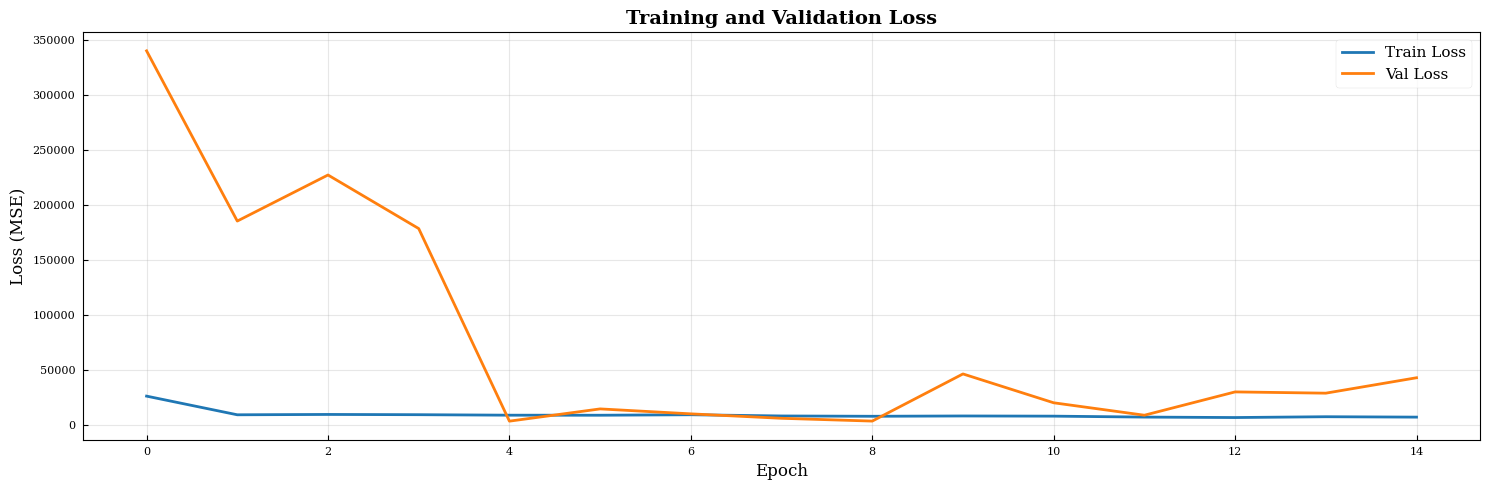

In [29]:
# Plot training curves
if "history" in locals():
    fig, ax = plt.subplots(1, 1, figsize=(15, 5))

    # Plot loss
    ax.plot(history.history["loss"], label="Train Loss", linewidth=2)
    ax.plot(history.history["val_loss"], label="Val Loss", linewidth=2)
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Loss (MSE)", fontsize=12)
    ax.set_title("Training and Validation Loss", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    # plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Training history not available. Train the model first.")

## Model Evaluation and Predictions

In [30]:
# Make predictions on test set
y_fnl_true_list = []
y_phi_true_list = []
y_fnl_pred_list = []
y_phi_pred_list = []

for batch_x, batch_y in test_ds_dual:
    fnl_pred, phi_pred = model.predict(batch_x, verbose=0)
    y_fnl_true_list.append(batch_y["fnl_output"].numpy())
    y_phi_true_list.append(batch_y["phi_output"].numpy())
    y_fnl_pred_list.append(fnl_pred)
    y_phi_pred_list.append(phi_pred)

y_fnl_true = np.concatenate(y_fnl_true_list, axis=0)
y_phi_true = np.concatenate(y_phi_true_list, axis=0)
y_fnl_pred = np.concatenate(y_fnl_pred_list, axis=0)
y_phi_pred = np.concatenate(y_phi_pred_list, axis=0)

print("=" * 60)
print("Performance Metrics")
print("=" * 60)

# fnl metrics (one per shape)
for i, shape in enumerate(dataset.shapes):
    mae = np.mean(np.abs(y_fnl_true[:, i] - y_fnl_pred[:, i]))
    rmse = np.sqrt(np.mean((y_fnl_true[:, i] - y_fnl_pred[:, i]) ** 2))
    print(f"\nfnl ({shape}):")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")

# phi_scale metrics
mae_phi = np.mean(np.abs(y_phi_true - y_phi_pred))
rmse_phi = np.sqrt(np.mean((y_phi_true - y_phi_pred) ** 2))
print(f"\nphi_scale:")
print(f"  MAE:  {mae_phi:.4f}")
print(f"  RMSE: {rmse_phi:.4f}")

Performance Metrics

fnl (local):
  MAE:  47.9204
  RMSE: 58.3065

phi_scale:
  MAE:  24.7165
  RMSE: 28.4423


## Visualization: True vs Predicted Scatter Plots

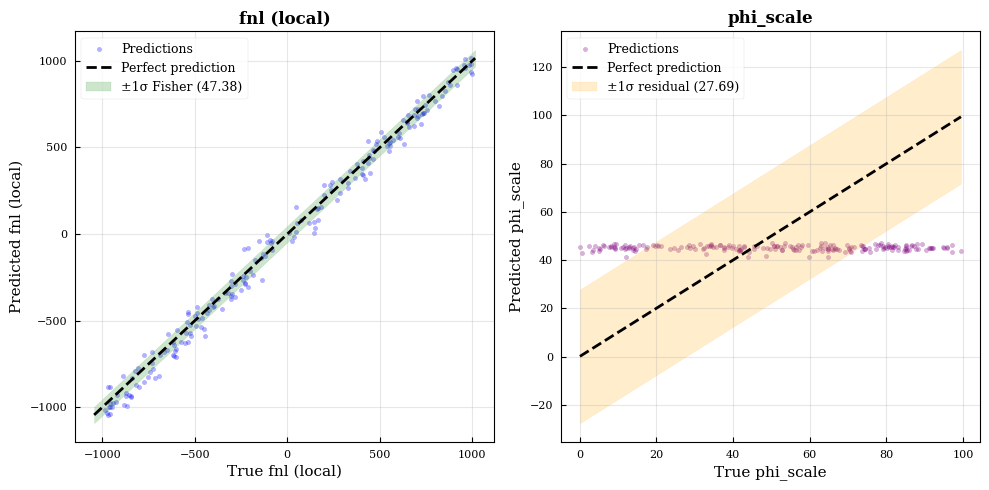

In [31]:
# True vs Predicted scatter plots with separate fnl and phi_scale
fig, axes = plt.subplots(1, nshapes + 1, figsize=(5 * (nshapes + 1), 5))

if isinstance(axes, np.ndarray):
    axes = axes.flat

# Plot fnl parameters
for i, ax in enumerate(axes[:nshapes]):
    shape_name = dataset.shapes[i]

    # Calculate residuals
    residuals = y_fnl_true[:, i] - y_fnl_pred[:, i]
    std_residual = np.std(residuals)

    # Scatter plot
    ax.scatter(
        y_fnl_true[:, i],
        y_fnl_pred[:, i],
        alpha=0.3,
        s=10,
        c="blue",
        label="Predictions",
    )

    # Perfect prediction line
    min_val = min(y_fnl_true[:, i].min(), y_fnl_pred[:, i].min())
    max_val = max(y_fnl_true[:, i].max(), y_fnl_pred[:, i].max())
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        "k--",
        linewidth=2,
        label="Perfect prediction",
    )

    # Error bands: Use Fisher matrix for fnl
    try:
        fisher = get_data(core.file, f"fisher/{dataset.l_str}/{shape_name}", 0)
        error_band = 1 / np.sqrt(fisher)
        label_band = f"±1σ Fisher ({error_band:.2f})"
        color_band = "green"
    except:
        error_band = std_residual
        label_band = f"±1σ residual ({error_band:.2f})"
        color_band = "red"

    ax.fill_between(
        np.linspace(min_val, max_val, 100),
        np.linspace(min_val, max_val, 100) - error_band,
        np.linspace(min_val, max_val, 100) + error_band,
        alpha=0.2,
        color=color_band,
        label=label_band,
    )

    ax.set_xlabel(f"True fnl ({shape_name})", fontsize=11)
    ax.set_ylabel(f"Predicted fnl ({shape_name})", fontsize=11)
    ax.set_title(f"fnl ({shape_name})", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Plot phi_scale
ax_phi = axes[nshapes]
residuals_phi = y_phi_true.flatten() - y_phi_pred.flatten()
std_residual_phi = np.std(residuals_phi)

ax_phi.scatter(y_phi_true, y_phi_pred, alpha=0.3, s=10, c="purple", label="Predictions")

min_val_phi = min(y_phi_true.min(), y_phi_pred.min())
max_val_phi = max(y_phi_true.max(), y_phi_pred.max())
ax_phi.plot(
    [min_val_phi, max_val_phi],
    [min_val_phi, max_val_phi],
    "k--",
    linewidth=2,
    label="Perfect prediction",
)

ax_phi.fill_between(
    np.linspace(min_val_phi, max_val_phi, 100),
    np.linspace(min_val_phi, max_val_phi, 100) - std_residual_phi,
    np.linspace(min_val_phi, max_val_phi, 100) + std_residual_phi,
    alpha=0.2,
    color="orange",
    label=f"±1σ residual ({std_residual_phi:.2f})",
)

ax_phi.set_xlabel("True phi_scale", fontsize=11)
ax_phi.set_ylabel("Predicted phi_scale", fontsize=11)
ax_phi.set_title("phi_scale", fontsize=12, fontweight="bold")
ax_phi.legend(fontsize=9)
ax_phi.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Residual Distributions

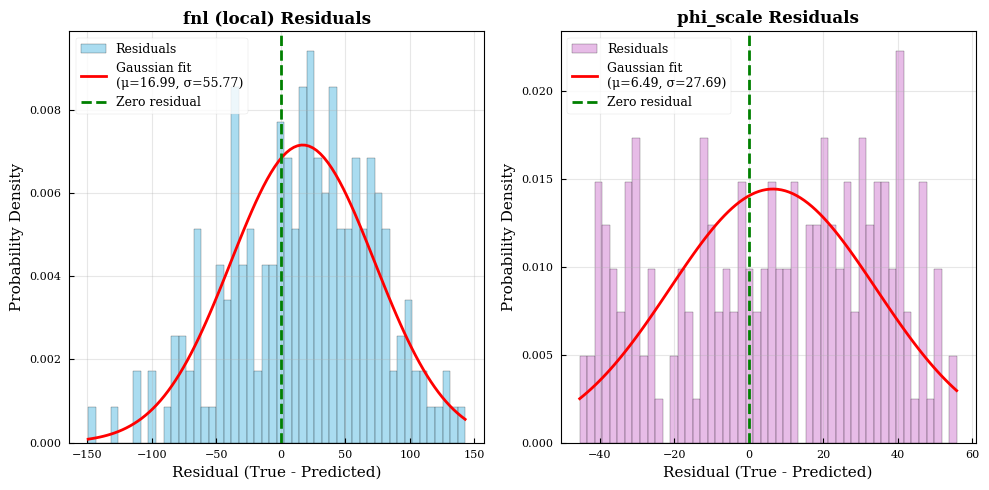

In [32]:
# Residual distributions for fnl and phi_scale
fig, axes = plt.subplots(1, nshapes + 1, figsize=(5 * (nshapes + 1), 5))

if isinstance(axes, np.ndarray):
    axes = axes.flat

# fnl residuals
for i, ax in enumerate(axes[:nshapes]):
    shape_name = dataset.shapes[i]
    residuals = y_fnl_true[:, i] - y_fnl_pred[:, i]

    # Histogram
    n, bins, patches = ax.hist(
        residuals,
        bins=50,
        density=True,
        alpha=0.7,
        color="skyblue",
        edgecolor="black",
        label="Residuals",
    )

    # Fit Gaussian
    mu = np.mean(residuals)
    sigma = np.std(residuals)
    x = np.linspace(residuals.min(), residuals.max(), 100)
    gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(
        -0.5 * ((x - mu) / sigma) ** 2
    )
    ax.plot(
        x,
        gaussian,
        "r-",
        linewidth=2,
        label=f"Gaussian fit\n(μ={mu:.2f}, σ={sigma:.2f})",
    )

    ax.axvline(0, color="green", linestyle="--", linewidth=2, label="Zero residual")
    ax.set_xlabel(f"Residual (True - Predicted)", fontsize=11)
    ax.set_ylabel("Probability Density", fontsize=11)
    ax.set_title(f"fnl ({shape_name}) Residuals", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# phi_scale residuals
ax_phi = axes[nshapes]
residuals_phi = y_phi_true.flatten() - y_phi_pred.flatten()

n, bins, patches = ax_phi.hist(
    residuals_phi,
    bins=50,
    density=True,
    alpha=0.7,
    color="plum",
    edgecolor="black",
    label="Residuals",
)

mu_phi = np.mean(residuals_phi)
sigma_phi = np.std(residuals_phi)
x_phi = np.linspace(residuals_phi.min(), residuals_phi.max(), 100)
gaussian_phi = (1 / (sigma_phi * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x_phi - mu_phi) / sigma_phi) ** 2
)
ax_phi.plot(
    x_phi,
    gaussian_phi,
    "r-",
    linewidth=2,
    label=f"Gaussian fit\n(μ={mu_phi:.2f}, σ={sigma_phi:.2f})",
)

ax_phi.axvline(0, color="green", linestyle="--", linewidth=2, label="Zero residual")
ax_phi.set_xlabel(f"Residual (True - Predicted)", fontsize=11)
ax_phi.set_ylabel("Probability Density", fontsize=11)
ax_phi.set_title("phi_scale Residuals", fontsize=12, fontweight="bold")
ax_phi.legend(fontsize=9)
ax_phi.grid(alpha=0.3)

plt.tight_layout()
plt.show()